In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import scipy.stats as st
import scipy.special as sp
import scipy.signal as sig
import matplotlib.pyplot as plt

import noisefinder as nf

%matplotlib ipympl

Text(0.5, 1.0, 'Generated data')

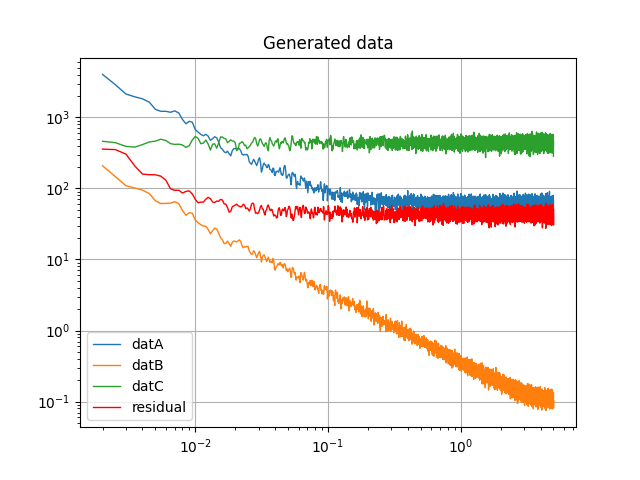

In [4]:
# just generate some data. make them correlated so that we test the entire method.
datres = np.cumsum(st.norm.rvs(size=210000))+100*st.norm.rvs(size=210000)
datB = 0.5*np.cumsum(st.norm.rvs(size=210000))
datC = 1000*st.norm.rvs(size=210000)
datA = datres+19*datB+0.10*datC
datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window='blackmanharris',nperseg=20000)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1,label='datB')
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1,label='datC')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')
ax.grid()
ax.legend()
ax.set_title('Generated data')

In [5]:
#calculate with LPF method
LPFfrscheme = nf.freqschemes.lpfScheme(Lmax=10000, fmax=1, fs=10)
CPSDresult  = nf.cpsd.CPSDevaluate(ts=meas,freqscheme=LPFfrscheme)

#extract parameters
CPSDresult.cohere
CPSDresult.CPSD
CPSDresult.PSD
CPSDresult.freqs
CPSDresult.Ls
CPSDresult.matp
CPSDresult.navs
CPSDresult.win


<function noisefinder.specwindows.BH92(M: int)>

In [7]:
# now perform noise projection and retrieve residual
mfnp = nf.noiseproj.NoiseProj(CPSDmat=CPSDresult.CPSD,navs=CPSDresult.navs)

ASDres_2sigma = nf.noiseproj.ASDresidualCI(mfnp,cval=0.95)

meas_alpre, meas_alpim = nf.noiseproj.alpProjCI(mfnp,cval=0.68)

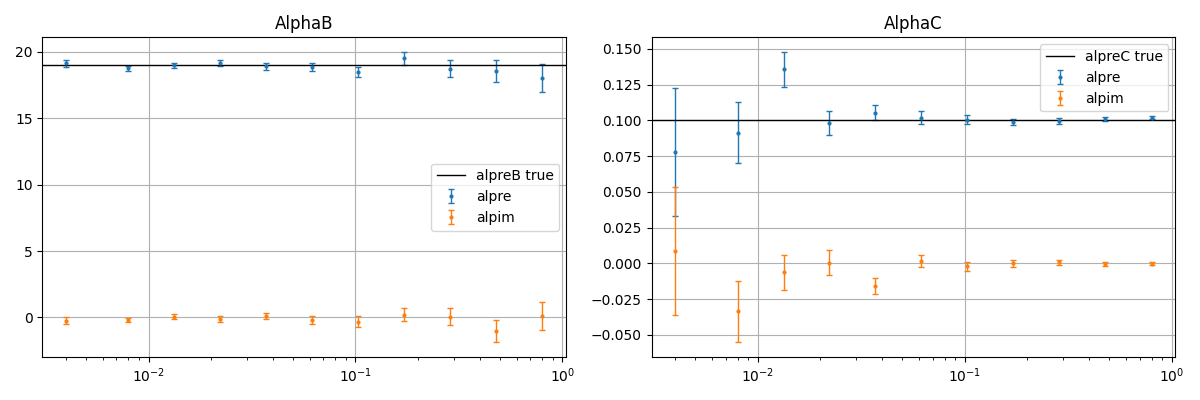

In [14]:
fig,ax=plt.subplots(1,2,figsize=(12,4),sharex=True)

#plot alphas
tsidx = 0
ax[0].errorbar(CPSDresult.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[0].axhline(19,c='k',lw=1,label='alpreB true')
ax[0].errorbar(CPSDresult.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[0].set_xscale('log')
ax[0].grid()
ax[0].set_title('AlphaB')
ax[0].legend()

tsidx = 1
ax[1].errorbar(CPSDresult.freqs,
            meas_alpre[:,tsidx,1],
            yerr = [meas_alpre[:,tsidx,1]-meas_alpre[:,tsidx,0],meas_alpre[:,tsidx,2]-meas_alpre[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpre')
ax[1].axhline(0.1,c='k',lw=1,label='alpreC true')
ax[1].errorbar(CPSDresult.freqs,
            meas_alpim[:,tsidx,1],
            yerr = [meas_alpim[:,tsidx,1]-meas_alpim[:,tsidx,0],meas_alpim[:,tsidx,2]-meas_alpim[:,tsidx,1]],
            linestyle='',capsize=2.5,lw=1,fmt='.',markersize=4,label='alpim')
ax[1].set_xscale('log')
ax[1].set_title('AlphaC')
ax[1].grid()
ax[1].legend()
fig.tight_layout()

plt.show()